# 🔁 Cross-Validation — Reliable Model Evaluation

> **Folder:** `05_Model_Evaluation`  
> **Notebook:** `cross_validation.ipynb`  
> **Author:** Hamna Munir

---

## 🎯 Objectives

By the end of this notebook, you will:

- Understand **why a single train/test split is unreliable**
- Implement **K-Fold, Stratified K-Fold, and Leave-One-Out** CV
- Use **cross_val_score** and **cross_validate** for multi-metric evaluation
- Build **CV learning curves** to diagnose bias and variance
- Perform **nested CV** for simultaneous tuning and evaluation
- Understand **time series CV** (no data leakage across time)
- Use CV correctly **inside a Pipeline** to prevent data leakage

---

## 📚 Techniques Covered

| # | Technique | Key Insight |
|---|-----------|-------------|
| 1 | Dataset Setup | Balanced + imbalanced + regression data |
| 2 | Holdout vs K-Fold | Why single splits are high-variance |
| 3 | K-Fold CV | Standard 5/10-fold evaluation |
| 4 | Stratified K-Fold | Preserves class ratio in each fold |
| 5 | Leave-One-Out (LOO) | n-fold CV for tiny datasets |
| 6 | cross_validate | Multiple metrics in one call |
| 7 | Learning Curves | Diagnose bias vs variance |
| 8 | Validation Curves | Find optimal hyperparameter |
| 9 | Nested CV | Unbiased tuning + evaluation |
| 10 | Time Series CV | Prevent leakage across time |
| 11 | CV in a Pipeline | Correct scaling inside folds |
| 12 | Summary & Golden Rules | Key takeaways |


---
## ⚙️ 0. Setup & Imports

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import (
    train_test_split,
    KFold, StratifiedKFold, LeaveOneOut,
    cross_val_score, cross_validate,
    learning_curve, validation_curve,
    GridSearchCV, TimeSeriesSplit,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    make_scorer, mean_squared_error, r2_score
)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

COLORS = {
    'primary'  : '#2E86AB',
    'secondary': '#E84855',
    'accent'   : '#3BB273',
    'warning'  : '#F18F01',
    'purple'   : '#7B2D8B',
    'palette'  : ['#2E86AB','#E84855','#3BB273','#F18F01','#7B2D8B','#F4D35E'],
}
print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


---
## 1️⃣ Dataset Setup

> Three datasets for different CV demonstrations:
> - **Binary classification** (balanced) — primary dataset
> - **Imbalanced binary** — for Stratified K-Fold demo
> - **Regression** — for regression CV + learning curves


In [16]:
np.random.seed(42)

# Binary balanced
X_clf, y_clf = make_classification(
    n_samples=500, n_features=15, n_informative=8,
    n_redundant=3, n_classes=2, weights=[0.5, 0.5],
    random_state=42
)

# Imbalanced binary (80:20)
X_imb, y_imb = make_classification(
    n_samples=500, n_features=15, n_informative=8,
    n_redundant=3, n_classes=2, weights=[0.80, 0.20],
    random_state=42
)

# Regression
X_reg, y_reg = make_regression(
    n_samples=400, n_features=10, n_informative=6,
    noise=15, random_state=42
)

# Small dataset for LOO demo
X_small, y_small = make_classification(
    n_samples=40, n_features=5, n_informative=4,
    n_redundant=0,   # ← fix: 4+0=4 < 5 ✅
    n_classes=2, random_state=42
)

print(f'Classification  : X={X_clf.shape}  |  classes={dict(pd.Series(y_clf).value_counts().sort_index())}')
print(f'Imbalanced      : X={X_imb.shape}  |  classes={dict(pd.Series(y_imb).value_counts().sort_index())}')
print(f'Regression      : X={X_reg.shape}')
print(f'Small (LOO)     : X={X_small.shape}')

Classification  : X=(500, 15)  |  classes={0: 249, 1: 251}
Imbalanced      : X=(500, 15)  |  classes={0: 396, 1: 104}
Regression      : X=(400, 10)
Small (LOO)     : X=(40, 5)


---
## 2️⃣ Holdout vs K-Fold — Why Single Splits are Unreliable

> A single train/test split gives **one estimate** of performance.  
> But that estimate has **high variance** — it depends heavily on which  
> samples land in the test set by chance.
>
> **K-Fold CV** repeats the evaluation K times on different splits,  
> giving a more reliable estimate with a confidence interval.


Holdout (20 random splits):
  Scores : [0.78, 0.78, 0.77, 0.74, 0.73, 0.73, 0.73, 0.73, 0.7, 0.72, 0.76, 0.74, 0.73, 0.82, 0.78, 0.74, 0.71, 0.69, 0.74, 0.71]
  Mean   : 0.7415
  Std    : 0.0310  ← HIGH variance!

5-Fold Cross-Validation:
  Scores : [0.75, 0.73, 0.73, 0.84, 0.68]
  Mean   : 0.7460
  Std    : 0.0524  ← lower variance


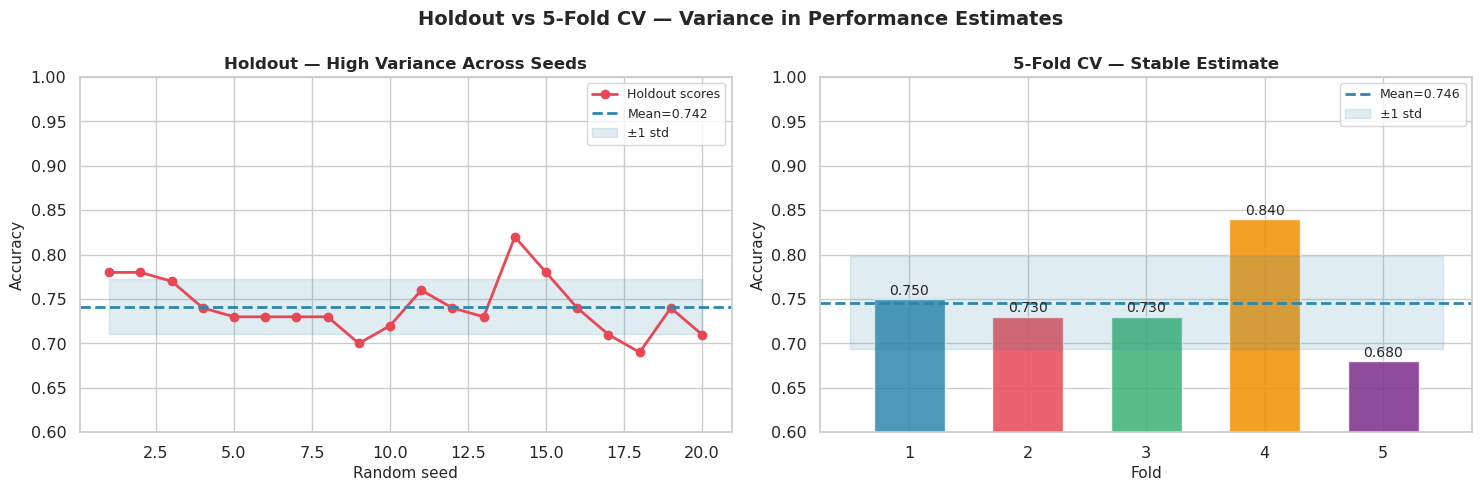

In [17]:
model = LogisticRegression(random_state=42, max_iter=1000)
scaler = StandardScaler()

# ── 20 different random holdout splits ────────────────────────────────────
holdout_scores = []
for seed in range(20):
    Xtr, Xte, ytr, yte = train_test_split(
        X_clf, y_clf, test_size=0.2, random_state=seed)
    Xtr = scaler.fit_transform(Xtr)
    Xte = scaler.transform(Xte)
    model.fit(Xtr, ytr)
    holdout_scores.append(accuracy_score(yte, model.predict(Xte)))

# ── 5-Fold CV (repeated 20 times via different seeds conceptually) ─────────
pipe = Pipeline([('sc', StandardScaler()), ('lr', LogisticRegression(max_iter=1000))])
kf_scores = cross_val_score(pipe, X_clf, y_clf, cv=5, scoring='accuracy')

print('Holdout (20 random splits):')
print(f'  Scores : {[round(s,4) for s in holdout_scores]}')
print(f'  Mean   : {np.mean(holdout_scores):.4f}')
print(f'  Std    : {np.std(holdout_scores):.4f}  ← HIGH variance!')
print()
print('5-Fold Cross-Validation:')
print(f'  Scores : {[round(s,4) for s in kf_scores]}')
print(f'  Mean   : {kf_scores.mean():.4f}')
print(f'  Std    : {kf_scores.std():.4f}  ← lower variance')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(range(1,21), holdout_scores, 'o-',
             color=COLORS['secondary'], linewidth=2, markersize=6, label='Holdout scores')
axes[0].axhline(np.mean(holdout_scores), color=COLORS['primary'],
                linestyle='--', linewidth=2, label=f'Mean={np.mean(holdout_scores):.3f}')
axes[0].fill_between(range(1,21),
                     np.mean(holdout_scores)-np.std(holdout_scores),
                     np.mean(holdout_scores)+np.std(holdout_scores),
                     alpha=0.15, color=COLORS['primary'], label='±1 std')
axes[0].set_xlabel('Random seed', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Holdout — High Variance Across Seeds', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_ylim([0.6, 1.0])

axes[1].bar(range(1, 6), kf_scores, color=COLORS['palette'][:5],
            alpha=0.85, edgecolor='white', width=0.6)
axes[1].axhline(kf_scores.mean(), color=COLORS['primary'],
                linestyle='--', linewidth=2, label=f'Mean={kf_scores.mean():.3f}')
axes[1].fill_between([0.5, 5.5],
                     kf_scores.mean()-kf_scores.std(),
                     kf_scores.mean()+kf_scores.std(),
                     alpha=0.15, color=COLORS['primary'], label='±1 std')
for i, s in enumerate(kf_scores):
    axes[1].text(i+1, s+0.005, f'{s:.3f}', ha='center', fontsize=10)
axes[1].set_xlabel('Fold', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_title('5-Fold CV — Stable Estimate', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_ylim([0.6, 1.0])
axes[1].set_xticks(range(1,6))

plt.suptitle('Holdout vs 5-Fold CV — Variance in Performance Estimates',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3️⃣ K-Fold Cross-Validation

> K-Fold splits data into K equal folds.  
> Each fold serves as the **test set once** while the remaining K−1 folds train.
>
> ```
> K=5:
>   Fold 1: [TEST ][TRAIN][TRAIN][TRAIN][TRAIN]
>   Fold 2: [TRAIN][TEST ][TRAIN][TRAIN][TRAIN]
>   Fold 3: [TRAIN][TRAIN][TEST ][TRAIN][TRAIN]
>   Fold 4: [TRAIN][TRAIN][TRAIN][TEST ][TRAIN]
>   Fold 5: [TRAIN][TRAIN][TRAIN][TRAIN][TEST ]
> ```
>
> **K=5** → 5 scores, each using 80% train / 20% test  
> **K=10** → more reliable but 2× slower


  K= 3 | scores=[0.7425, 0.6946, 0.7349]
        mean=0.7240 | std=0.0210 | 95% CI=[0.6820, 0.7661]

  K= 5 | scores=[0.75, 0.73, 0.7, 0.74, 0.7]
        mean=0.7240 | std=0.0206 | 95% CI=[0.6828, 0.7652]

  K=10 | scores=[0.82, 0.68, 0.78, 0.7, 0.72, 0.72, 0.72, 0.8, 0.74, 0.7]
        mean=0.7380 | std=0.0442 | 95% CI=[0.6495, 0.8265]

  K=20 | scores=[0.88, 0.72, 0.6, 0.76, 0.88, 0.68, 0.64, 0.76, 0.72, 0.72, 0.72, 0.72, 0.72, 0.72, 0.84, 0.76, 0.72, 0.8, 0.64, 0.76]
        mean=0.7380 | std=0.0710 | 95% CI=[0.5961, 0.8799]



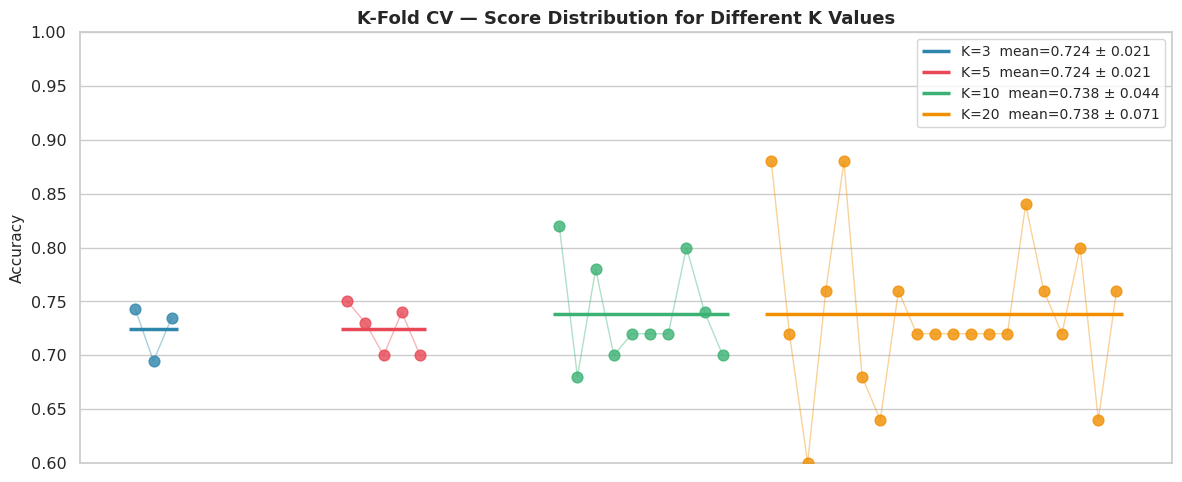

In [18]:
pipe = Pipeline([('sc', StandardScaler()),
                ('lr', LogisticRegression(max_iter=1000, random_state=42))])

results = {}
for k in [3, 5, 10, 20]:
    kf     = KFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X_clf, y_clf, cv=kf, scoring='accuracy')
    results[k] = scores
    print(f'  K={k:2d} | scores={[round(s,4) for s in scores]}')
    print(f'        mean={scores.mean():.4f} | std={scores.std():.4f} | '
          f'95% CI=[{scores.mean()-2*scores.std():.4f}, {scores.mean()+2*scores.std():.4f}]')
    print()

fig, ax = plt.subplots(figsize=(12, 5))
positions = []
all_scores = []
labels = []
for i, (k, scores) in enumerate(results.items()):
    pos = [i*2 + j*0.35 for j in range(len(scores))]
    positions.extend(pos)
    all_scores.extend(scores)
    labels.append(f'K={k}')

for i, (k, scores) in enumerate(results.items()):
    x_pos = np.arange(len(scores)) * 0.3 + i * 3.5
    ax.scatter(x_pos, scores, color=COLORS['palette'][i],
               s=60, alpha=0.8, zorder=3)
    ax.plot(x_pos, scores, color=COLORS['palette'][i],
            alpha=0.4, linewidth=1)
    ax.hlines(scores.mean(), x_pos[0]-0.1, x_pos[-1]+0.1,
              color=COLORS['palette'][i], linewidth=2.5,
              label=f'K={k}  mean={scores.mean():.3f} ± {scores.std():.3f}')

ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('K-Fold CV — Score Distribution for Different K Values',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim([0.6, 1.0])
ax.set_xticks([])
plt.tight_layout()
plt.show()

---
## 4️⃣ Stratified K-Fold — Preserving Class Ratios

> Standard K-Fold splits data **randomly** — on imbalanced datasets,  
> some folds may have very few minority class samples or none at all.
>
> **Stratified K-Fold** ensures each fold has the **same class ratio** as the full dataset.
>
> ✅ Always use `StratifiedKFold` for classification — it's strictly better.


Class ratios per fold — KFold vs StratifiedKFold (imbalanced 80:20 data)
Fold   KFold (class 1 %)      StratifiedKFold (class 1 %) 
----------------------------------------------------------
  1        23.0%                    20.0%
  2        18.0%                    21.0%
  3        19.0%                    21.0%
  4        22.0%                    21.0%
  5        22.0%                    21.0%

KFold F1 scores       : [0.6452, 0.4583, 0.5424, 0.5, 0.5926]
  mean=0.5477 | std=0.0660

StratifiedKFold F1    : [0.5957, 0.6038, 0.4314, 0.5714, 0.5902]
  mean=0.5585 | std=0.0644


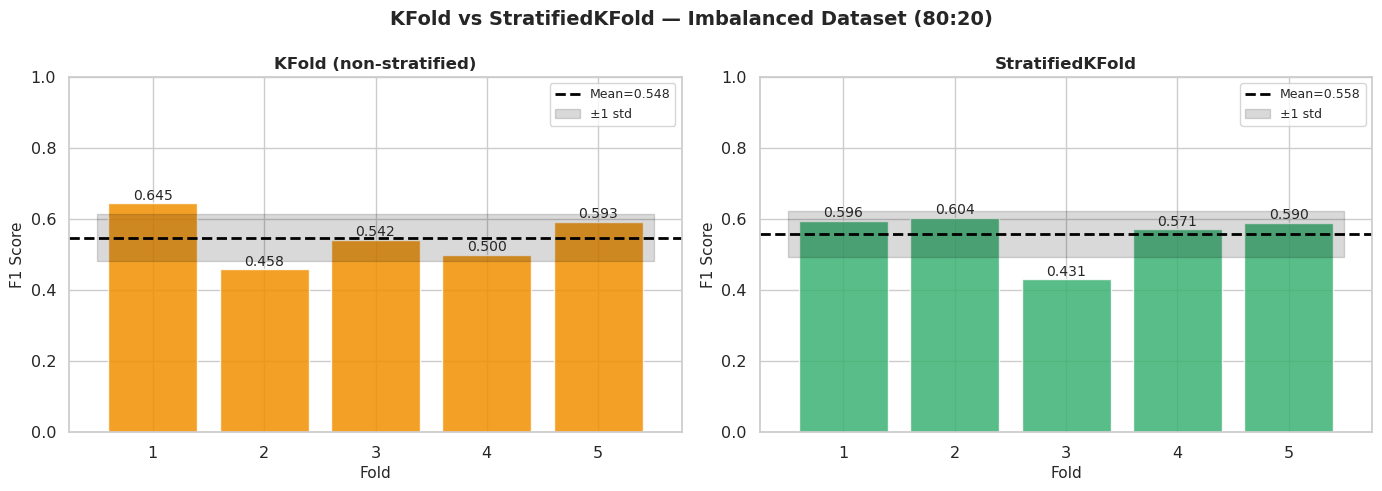

In [19]:
pipe_imb = Pipeline([
    ('sc', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

kf_plain = KFold(n_splits=5, shuffle=True, random_state=42)
kf_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Check class ratios per fold
print('Class ratios per fold — KFold vs StratifiedKFold (imbalanced 80:20 data)')
print(f'{"Fold":<6} {"KFold (class 1 %)":<22} {"StratifiedKFold (class 1 %)":<28}')
print('-' * 58)

for fold, (kf_idx, skf_idx) in enumerate(
        zip(kf_plain.split(X_imb, y_imb), kf_strat.split(X_imb, y_imb))):
    _, kf_te  = kf_idx
    _, skf_te = skf_idx
    kf_ratio  = y_imb[kf_te].mean()
    skf_ratio = y_imb[skf_te].mean()
    print(f'  {fold+1}    {kf_ratio*100:>8.1f}%                {skf_ratio*100:>8.1f}%')

print()
# Compare scores
scores_kf  = cross_val_score(pipe_imb, X_imb, y_imb, cv=kf_plain,  scoring='f1')
scores_skf = cross_val_score(pipe_imb, X_imb, y_imb, cv=kf_strat, scoring='f1')

print(f'KFold F1 scores       : {[round(s,4) for s in scores_kf]}')
print(f'  mean={scores_kf.mean():.4f} | std={scores_kf.std():.4f}')
print()
print(f'StratifiedKFold F1    : {[round(s,4) for s in scores_skf]}')
print(f'  mean={scores_skf.mean():.4f} | std={scores_skf.std():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, scores, title, color in zip(
        axes,
        [scores_kf, scores_skf],
        ['KFold (non-stratified)', 'StratifiedKFold'],
        [COLORS['warning'], COLORS['accent']]):
    ax.bar(range(1, 6), scores, color=color, alpha=0.85, edgecolor='white')
    ax.axhline(scores.mean(), color='black', linestyle='--', linewidth=2,
               label=f'Mean={scores.mean():.3f}')
    ax.fill_between([0.5,5.5],
                    scores.mean()-scores.std(),
                    scores.mean()+scores.std(),
                    alpha=0.15, color='black', label='±1 std')
    for i, s in enumerate(scores):
        ax.text(i+1, s+0.01, f'{s:.3f}', ha='center', fontsize=10)
    ax.set_xlabel('Fold', fontsize=11); ax.set_ylabel('F1 Score', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9); ax.set_ylim([0, 1.0]); ax.set_xticks(range(1,6))

plt.suptitle('KFold vs StratifiedKFold — Imbalanced Dataset (80:20)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5️⃣ Leave-One-Out CV (LOO)

> LOO is K-Fold where **K = n** — each sample is the test set once.
>
> | Property | LOO | K-Fold |
> |----------|:---:|:------:|
> | Test set size | 1 sample | n/K samples |
> | Folds | n | K |
> | Bias in evaluation | Very low | Low |
> | Computational cost | Very high O(n) | Low O(K) |
> | Best for | n < 50 | General use |
>
> ⚠️ Do NOT use LOO on large datasets — it will be extremely slow.


Dataset size : 40 samples

LOO  (40 folds): mean=0.7750 | std=0.4176
5-Fold        : mean=0.7000  | std=0.0612
10-Fold       : mean=0.8000  | std=0.1500


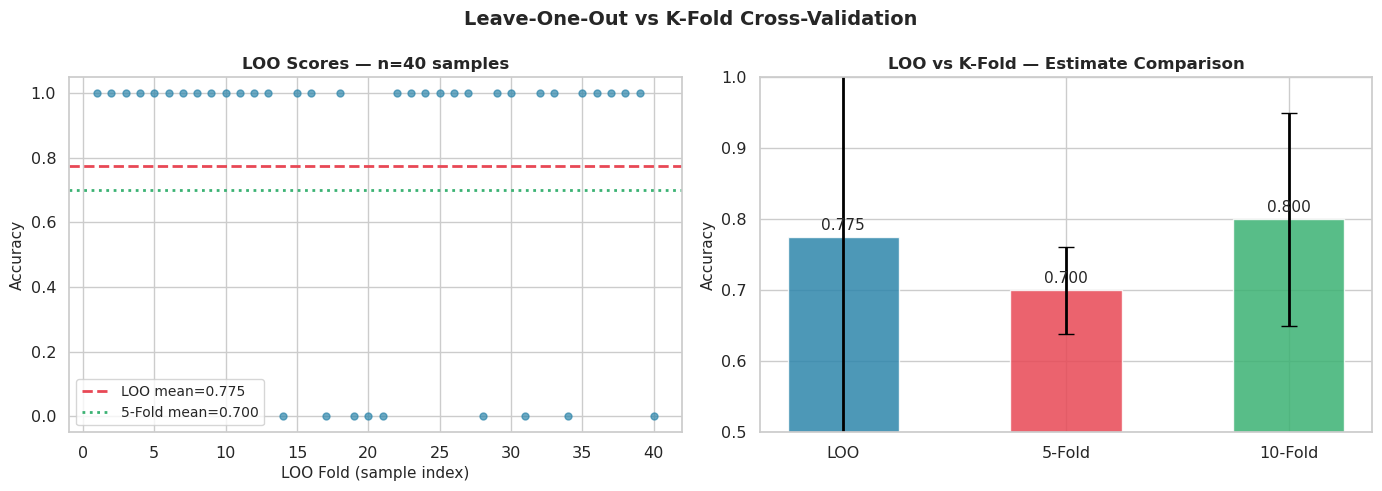

In [20]:
pipe_small = Pipeline([
    ('sc', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

loo    = LeaveOneOut()
skf_5  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores_loo  = cross_val_score(pipe_small, X_small, y_small, cv=loo,    scoring='accuracy')
scores_5f   = cross_val_score(pipe_small, X_small, y_small, cv=skf_5,  scoring='accuracy')
scores_10f  = cross_val_score(pipe_small, X_small, y_small, cv=skf_10, scoring='accuracy')

print(f'Dataset size : {len(X_small)} samples')
print()
print(f'LOO  ({len(scores_loo)} folds): mean={scores_loo.mean():.4f} | std={scores_loo.std():.4f}')
print(f'5-Fold        : mean={scores_5f.mean():.4f}  | std={scores_5f.std():.4f}')
print(f'10-Fold       : mean={scores_10f.mean():.4f}  | std={scores_10f.std():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(scores_loo)+1), scores_loo,
             'o', color=COLORS['primary'], markersize=5, alpha=0.7)
axes[0].axhline(scores_loo.mean(), color=COLORS['secondary'],
                linestyle='--', linewidth=2,
                label=f'LOO mean={scores_loo.mean():.3f}')
axes[0].axhline(scores_5f.mean(), color=COLORS['accent'],
                linestyle=':', linewidth=2,
                label=f'5-Fold mean={scores_5f.mean():.3f}')
axes[0].set_xlabel('LOO Fold (sample index)', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title(f'LOO Scores — n={len(X_small)} samples', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

methods = ['LOO', '5-Fold', '10-Fold']
means   = [scores_loo.mean(), scores_5f.mean(), scores_10f.mean()]
stds    = [scores_loo.std(),  scores_5f.std(),  scores_10f.std()]
bars = axes[1].bar(methods, means, color=COLORS['palette'][:3],
                   alpha=0.85, edgecolor='white', width=0.5)
axes[1].errorbar(methods, means, yerr=stds, fmt='none',
                 color='black', capsize=6, linewidth=2)
for bar, m in zip(bars, means):
    axes[1].text(bar.get_x()+bar.get_width()/2, m+0.01,
                 f'{m:.3f}', ha='center', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_title('LOO vs K-Fold — Estimate Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylim([0.5, 1.0])

plt.suptitle('Leave-One-Out vs K-Fold Cross-Validation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6️⃣ cross_validate — Multiple Metrics in One Call

> `cross_val_score` returns one metric.  
> `cross_validate` returns **multiple metrics + train scores + fit times** in one call.
>
> Always use `cross_validate` when you need more than one metric — it avoids re-running CV.


cross_validate — Multi-Metric Results (5-Fold, Random Forest)
   Metric  Train Mean  Train Std  Val Mean  Val Std  Overfit Gap
 accuracy      1.0000     0.0000    0.8320   0.0299       0.1680
       f1      1.0000     0.0000    0.8317   0.0348       0.1683
  roc_auc      1.0000     0.0000    0.9199   0.0119       0.0801
precision      1.0000     0.0000    0.8330   0.0226       0.1670
   recall      1.0000     0.0000    0.8327   0.0626       0.1673

Mean fit time  : 0.320s
Mean score time: 0.032s


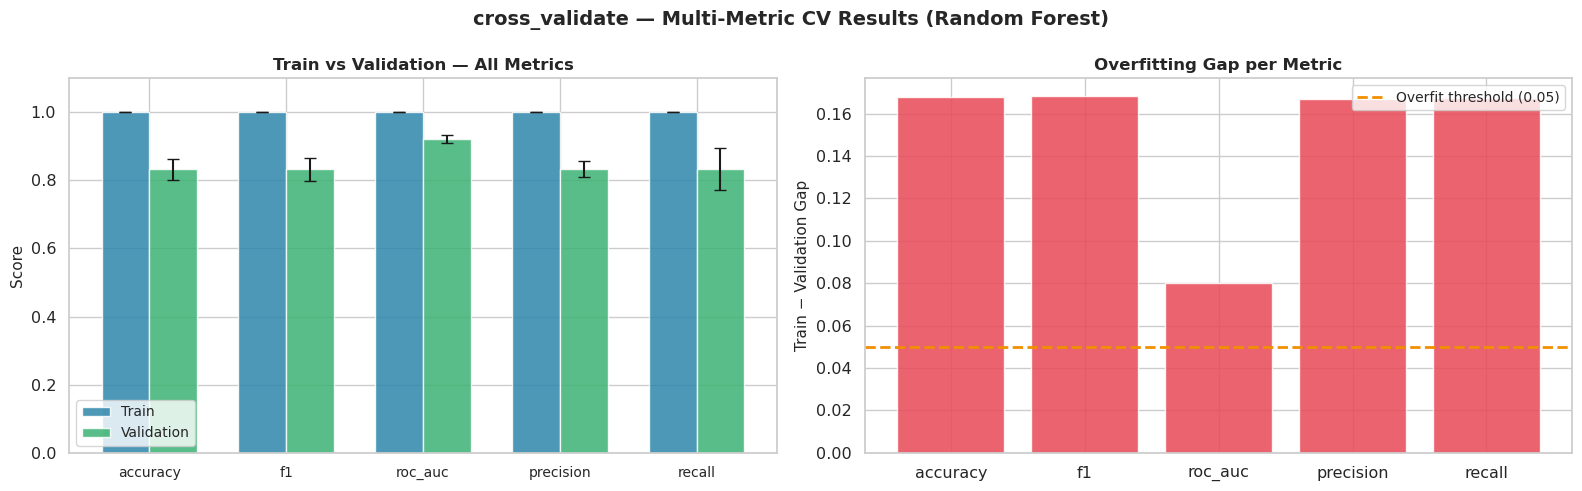

In [23]:
pipe_cv = Pipeline([
    ('sc',  StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    pipe_cv, X_clf, y_clf, cv=skf,
    scoring={
        'accuracy' : 'accuracy',
        'f1'       : 'f1',
        'roc_auc'  : 'roc_auc',
        'precision': 'precision',
        'recall'   : 'recall',
    },
    return_train_score=True,
    n_jobs=-1,
)

metrics_summary = []
for metric in ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']:
    train_key = f'train_{metric}'
    test_key  = f'test_{metric}'
    train_sc  = cv_results[train_key]
    test_sc   = cv_results[test_key]
    metrics_summary.append({
        'Metric'      : metric,
        'Train Mean'  : round(train_sc.mean(), 4),
        'Train Std'   : round(train_sc.std(), 4),
        'Val Mean'    : round(test_sc.mean(), 4),
        'Val Std'     : round(test_sc.std(), 4),
        'Overfit Gap' : round(train_sc.mean() - test_sc.mean(), 4),
    })

summary_df = pd.DataFrame(metrics_summary)
print('cross_validate — Multi-Metric Results (5-Fold, Random Forest)')
print(summary_df.to_string(index=False))
print(f'\nMean fit time  : {cv_results["fit_time"].mean():.3f}s')
print(f'Mean score time: {cv_results["score_time"].mean():.3f}s')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
metrics_plot = ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']
x = np.arange(len(metrics_plot))
width = 0.35

train_means = [cv_results[f'train_{m}'].mean() for m in metrics_plot]
test_means  = [cv_results[f'test_{m}'].mean()  for m in metrics_plot]
train_stds  = [cv_results[f'train_{m}'].std()  for m in metrics_plot]
test_stds   = [cv_results[f'test_{m}'].std()   for m in metrics_plot]

axes[0].bar(x - width/2, train_means, width, label='Train',
            color=COLORS['primary'], alpha=0.85, yerr=train_stds,
            capsize=4, error_kw={'linewidth':1.5})
axes[0].bar(x + width/2, test_means, width, label='Validation',
            color=COLORS['accent'], alpha=0.85, yerr=test_stds,
            capsize=4, error_kw={'linewidth':1.5})
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics_plot, fontsize=10)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Train vs Validation — All Metrics', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10); axes[0].set_ylim([0, 1.1])

gaps = [tm - vm for tm, vm in zip(train_means, test_means)]
colors_gap = [COLORS['secondary'] if g > 0.05 else COLORS['accent'] for g in gaps]
axes[1].bar(metrics_plot, gaps, color=colors_gap, alpha=0.85, edgecolor='white')
axes[1].axhline(0.05, color=COLORS['warning'], linestyle='--',
                linewidth=2, label='Overfit threshold (0.05)')
axes[1].set_ylabel('Train − Validation Gap', fontsize=11)
axes[1].set_title('Overfitting Gap per Metric', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('cross_validate — Multi-Metric CV Results (Random Forest)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7️⃣ Learning Curves — Diagnose Bias vs Variance

> Learning curves plot train and validation error **as a function of training set size**.
>
> | Pattern | Diagnosis | Fix |
> |---------|-----------|-----|
> | Both curves converge at HIGH error | High Bias (Underfitting) | More complex model / more features |
> | Large persistent gap, train low | High Variance (Overfitting) | Regularization / more data |
> | Both converge at LOW error | Good Fit ✅ | Deploy! |


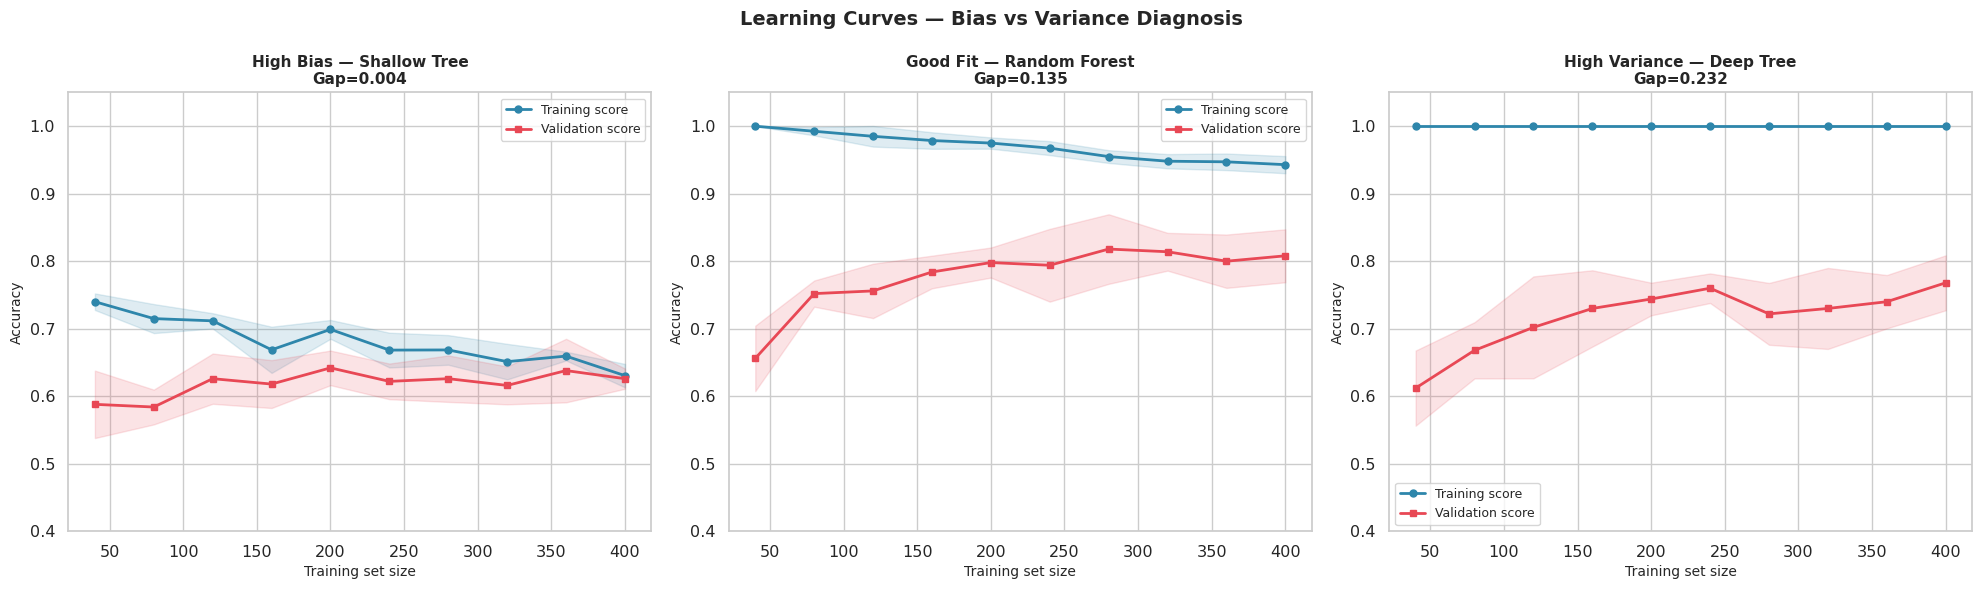

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

configs = [
    ('High Bias — Shallow Tree',
     DecisionTreeClassifier(max_depth=1, random_state=42)),
    ('Good Fit — Random Forest',
     RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)),
    ('High Variance — Deep Tree',
     DecisionTreeClassifier(max_depth=None, random_state=42)),
]

skf_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes_pct = np.linspace(0.1, 1.0, 10)

for ax, (title, estimator) in zip(axes, configs):
    pipe_lc = Pipeline([('sc', StandardScaler()), ('model', estimator)])
    train_sizes, train_scores, val_scores = learning_curve(
        pipe_lc, X_clf, y_clf,
        train_sizes=train_sizes_pct,
        cv=skf_lc,
        scoring='accuracy',
        n_jobs=-1,
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color=COLORS['primary'],
            linewidth=2, markersize=5, label='Training score')
    ax.fill_between(train_sizes,
                    train_mean - train_std,
                    train_mean + train_std,
                    alpha=0.15, color=COLORS['primary'])

    ax.plot(train_sizes, val_mean, 's-', color=COLORS['secondary'],
            linewidth=2, markersize=5, label='Validation score')
    ax.fill_between(train_sizes,
                    val_mean - val_std,
                    val_mean + val_std,
                    alpha=0.15, color=COLORS['secondary'])

    final_gap = train_mean[-1] - val_mean[-1]
    ax.set_xlabel('Training set size', fontsize=10)
    ax.set_ylabel('Accuracy', fontsize=10)
    ax.set_title(f'{title}\nGap={final_gap:.3f}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9); ax.set_ylim([0.4, 1.05])

plt.suptitle('Learning Curves — Bias vs Variance Diagnosis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8️⃣ Validation Curves — Find the Optimal Hyperparameter

> A validation curve plots train and validation score  
> **as a function of a single hyperparameter value**.
>
> - Left side → model too simple (high bias / underfitting)
> - Right side → model too complex (high variance / overfitting)
> - Sweet spot → **elbow** where validation score peaks


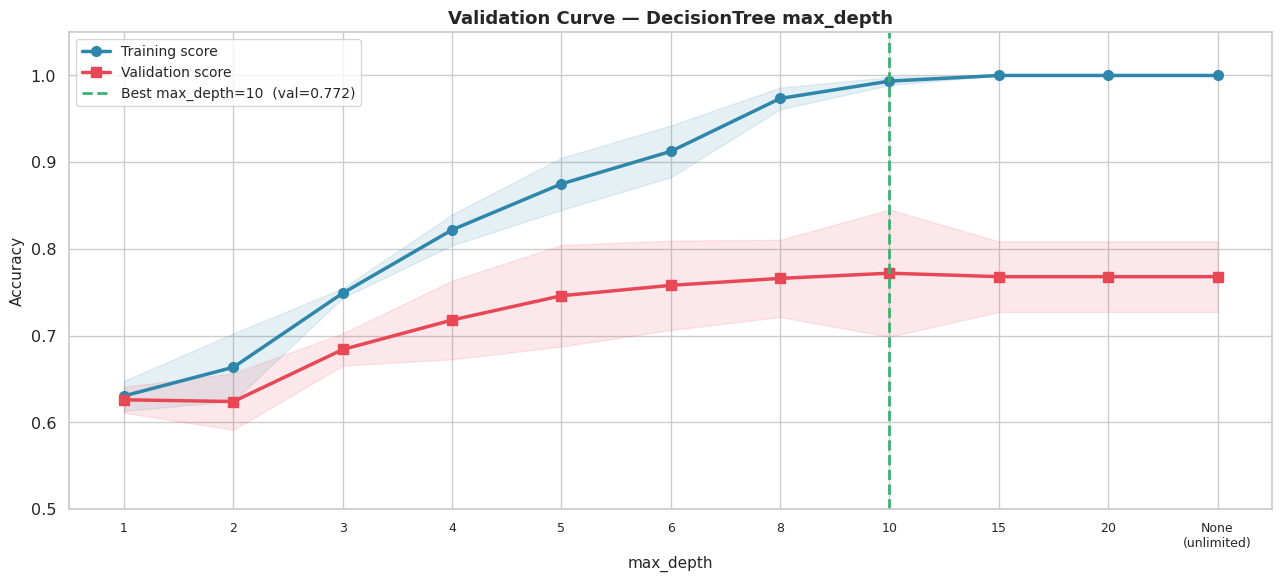

Optimal max_depth = 10
  Train score: 0.9935 ± 0.0046
  Val score  : 0.7720 ± 0.0733
  Overfit gap: 0.2215


In [25]:
pipe_vc = Pipeline([
    ('sc',  StandardScaler()),
    ('clf', DecisionTreeClassifier(random_state=42))
])

skf_vc   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_range = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, None]
param_labels = [str(p) if p is not None else 'None\n(unlimited)' for p in param_range]

train_scores, val_scores = validation_curve(
    pipe_vc, X_clf, y_clf,
    param_name='clf__max_depth',
    param_range=param_range,
    cv=skf_vc,
    scoring='accuracy',
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

best_idx   = np.argmax(val_mean)
best_depth = param_range[best_idx]

fig, ax = plt.subplots(figsize=(13, 6))
x = range(len(param_range))

ax.plot(x, train_mean, 'o-', color=COLORS['primary'],
        linewidth=2.5, markersize=7, label='Training score')
ax.fill_between(x, train_mean-train_std, train_mean+train_std,
                alpha=0.12, color=COLORS['primary'])

ax.plot(x, val_mean, 's-', color=COLORS['secondary'],
        linewidth=2.5, markersize=7, label='Validation score')
ax.fill_between(x, val_mean-val_std, val_mean+val_std,
                alpha=0.12, color=COLORS['secondary'])

ax.axvline(best_idx, color=COLORS['accent'], linestyle='--',
           linewidth=2, label=f'Best max_depth={best_depth}  (val={val_mean[best_idx]:.3f})')

ax.set_xticks(x)
ax.set_xticklabels(param_labels, fontsize=9)
ax.set_xlabel('max_depth', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Validation Curve — DecisionTree max_depth',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim([0.5, 1.05])

plt.tight_layout()
plt.show()

print(f'Optimal max_depth = {best_depth}')
print(f'  Train score: {train_mean[best_idx]:.4f} ± {train_std[best_idx]:.4f}')
print(f'  Val score  : {val_mean[best_idx]:.4f} ± {val_std[best_idx]:.4f}')
print(f'  Overfit gap: {train_mean[best_idx]-val_mean[best_idx]:.4f}')

---
## 9️⃣ Nested Cross-Validation — Unbiased Evaluation with Tuning

> **Problem:** If you tune hyperparameters using CV, then evaluate with the same CV,  
> you get an **optimistically biased** estimate — the model has "seen" the test data.
>
> **Nested CV** uses:
> - **Inner CV** → hyperparameter tuning (GridSearchCV)
> - **Outer CV** → final performance evaluation (unbiased)
>
> ```
> Outer fold 1: [TEST] ← evaluate tuned model here
>   Inner CV on remaining: tune hyperparameters
> Outer fold 2: [TEST] ← evaluate independently tuned model
>   Inner CV on remaining: tune hyperparameters
> ...
> ```


Non-Nested CV (biased — hyperparams tuned on same data):
  Scores: [0.86, 0.78, 0.86, 0.84, 0.82]
  Mean  : 0.8320 ± 0.0299

Nested CV (unbiased — inner loop tunes, outer loop evaluates):
  Scores: [0.86, 0.78, 0.86, 0.84, 0.84]
  Mean  : 0.8360 ± 0.0294

Optimism bias (non-nested − nested): -0.0040
→ Positive bias = non-nested overestimates true performance


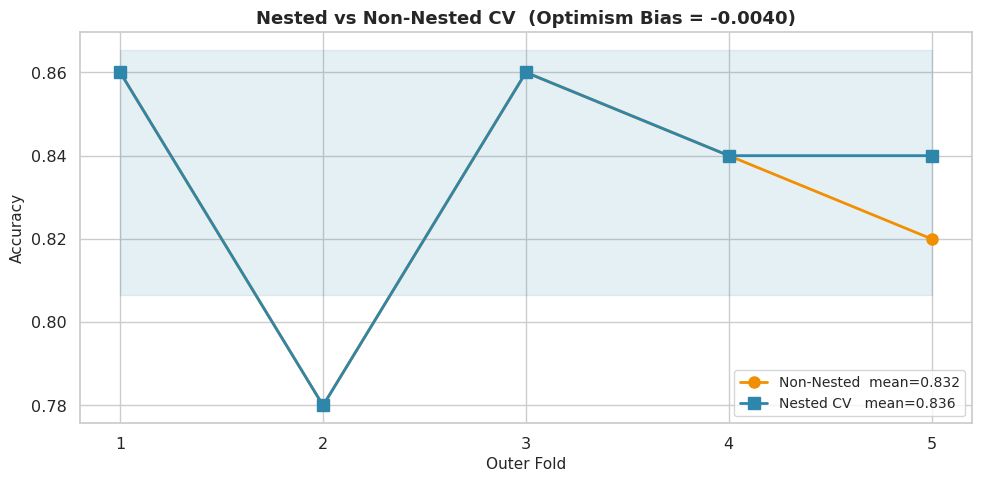

In [26]:
from sklearn.model_selection import GridSearchCV

pipe_nested = Pipeline([
    ('sc',  StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42))
])

param_grid = {
    'clf__n_estimators': [50, 100],
    'clf__max_depth'   : [3, 5, None],
    'clf__max_features': ['sqrt', 'log2'],
}

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# ── Non-nested: tune once, evaluate on same CV ────────────────────────────
gs_simple = GridSearchCV(pipe_nested, param_grid, cv=inner_cv,
                          scoring='accuracy', n_jobs=-1)
gs_simple.fit(
    StandardScaler().fit_transform(X_clf), y_clf
)
non_nested_scores = cross_val_score(
    gs_simple.best_estimator_, X_clf, y_clf,
    cv=outer_cv, scoring='accuracy'
)

# ── Nested: inner GridSearch inside each outer fold ───────────────────────
gs_nested = GridSearchCV(pipe_nested, param_grid, cv=inner_cv,
                          scoring='accuracy', n_jobs=-1)
nested_scores = cross_val_score(
    gs_nested, X_clf, y_clf,
    cv=outer_cv, scoring='accuracy',
    n_jobs=-1
)

print('Non-Nested CV (biased — hyperparams tuned on same data):')
print(f'  Scores: {[round(s,4) for s in non_nested_scores]}')
print(f'  Mean  : {non_nested_scores.mean():.4f} ± {non_nested_scores.std():.4f}')
print()
print('Nested CV (unbiased — inner loop tunes, outer loop evaluates):')
print(f'  Scores: {[round(s,4) for s in nested_scores]}')
print(f'  Mean  : {nested_scores.mean():.4f} ± {nested_scores.std():.4f}')
print()
bias = non_nested_scores.mean() - nested_scores.mean()
print(f'Optimism bias (non-nested − nested): {bias:+.4f}')
print('→ Positive bias = non-nested overestimates true performance')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1,6), non_nested_scores, 'o-', color=COLORS['warning'],
        linewidth=2, markersize=8, label=f'Non-Nested  mean={non_nested_scores.mean():.3f}')
ax.plot(range(1,6), nested_scores, 's-', color=COLORS['primary'],
        linewidth=2, markersize=8, label=f'Nested CV   mean={nested_scores.mean():.3f}')
ax.fill_between(range(1,6),
                nested_scores.mean()-nested_scores.std(),
                nested_scores.mean()+nested_scores.std(),
                alpha=0.12, color=COLORS['primary'])
ax.set_xlabel('Outer Fold', fontsize=11); ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title(f'Nested vs Non-Nested CV  (Optimism Bias = {bias:+.4f})',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.set_xticks(range(1,6))
plt.tight_layout(); plt.show()

---
## 🔟 Time Series Cross-Validation

> Standard K-Fold **shuffles** data — this causes **data leakage** in time series:  
> future data leaks into the training set.
>
> `TimeSeriesSplit` uses **expanding windows** — train always comes before test:
>
> ```
> Split 1: [TRAIN──────][TEST─]
> Split 2: [TRAIN──────────][TEST─]
> Split 3: [TRAIN──────────────][TEST─]
> Split 4: [TRAIN──────────────────][TEST─]
> Split 5: [TRAIN──────────────────────][TEST─]
> ```


TimeSeriesSplit (no leakage):
  Scores: [0.3, 0.7, 0.78, 0.86, 0.82]
  Mean  : 0.6920 ± 0.2030

StratifiedKFold (has leakage — shuffles time):
  Scores: [0.8167, 0.9333, 0.8167, 0.8667, 0.8833]
  Mean  : 0.8633 ± 0.0440


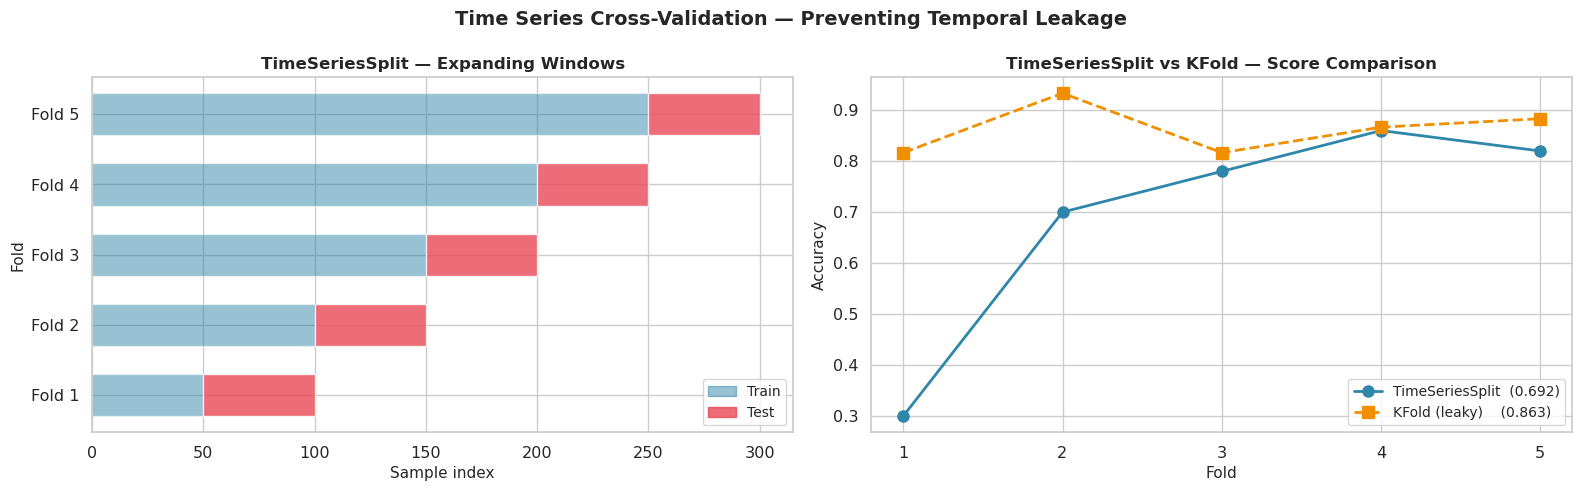

In [27]:
# Simulate time-ordered data
np.random.seed(42)
n_ts = 300
t    = np.arange(n_ts)
X_ts = np.column_stack([
    np.sin(0.05*t) + np.random.randn(n_ts)*0.3,
    np.cos(0.03*t) + np.random.randn(n_ts)*0.2,
    np.random.randn(n_ts),
    t / n_ts,
])
y_ts = (np.sin(0.05*t) + np.random.randn(n_ts)*0.5 > 0).astype(int)

tscv   = TimeSeriesSplit(n_splits=5)
skf_ts = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_ts = Pipeline([
    ('sc',  StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

scores_tscv = cross_val_score(pipe_ts, X_ts, y_ts, cv=tscv,   scoring='accuracy')
scores_kfts = cross_val_score(pipe_ts, X_ts, y_ts, cv=skf_ts, scoring='accuracy')

print('TimeSeriesSplit (no leakage):')
print(f'  Scores: {[round(s,4) for s in scores_tscv]}')
print(f'  Mean  : {scores_tscv.mean():.4f} ± {scores_tscv.std():.4f}')
print()
print('StratifiedKFold (has leakage — shuffles time):')
print(f'  Scores: {[round(s,4) for s in scores_kfts]}')
print(f'  Mean  : {scores_kfts.mean():.4f} ± {scores_kfts.std():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Visualize splits
for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_ts)):
    axes[0].barh(fold, len(tr_idx), left=0,
                 color=COLORS['primary'], alpha=0.5, height=0.6)
    axes[0].barh(fold, len(te_idx), left=len(tr_idx),
                 color=COLORS['secondary'], alpha=0.8, height=0.6)
axes[0].set_xlabel('Sample index', fontsize=11)
axes[0].set_ylabel('Fold', fontsize=11)
axes[0].set_yticks(range(5))
axes[0].set_yticklabels([f'Fold {i+1}' for i in range(5)])
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color=COLORS['primary'], alpha=0.5, label='Train'),
                          Patch(color=COLORS['secondary'], alpha=0.8, label='Test')],
               fontsize=10)
axes[0].set_title('TimeSeriesSplit — Expanding Windows', fontsize=12, fontweight='bold')

axes[1].plot(range(1,6), scores_tscv, 'o-', color=COLORS['primary'],
             linewidth=2, markersize=8, label=f'TimeSeriesSplit  ({scores_tscv.mean():.3f})')
axes[1].plot(range(1,6), scores_kfts, 's--', color=COLORS['warning'],
             linewidth=2, markersize=8, label=f'KFold (leaky)    ({scores_kfts.mean():.3f})')
axes[1].set_xlabel('Fold', fontsize=11); axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_title('TimeSeriesSplit vs KFold — Score Comparison',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10); axes[1].set_xticks(range(1,6))

plt.suptitle('Time Series Cross-Validation — Preventing Temporal Leakage',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 1️⃣1️⃣ CV Inside a Pipeline — Preventing Data Leakage

> **Critical rule:** Preprocessing (scaling, imputation, encoding) must be  
> **fitted only on the training fold** — never on the full dataset before CV.
>
> ✅ Always wrap preprocessing + model in a `Pipeline` before passing to CV.


⚠️  WRONG (scaling before CV — data leakage):
   Scores: [0.73, 0.73, 0.76, 0.78, 0.71]
   Mean  : 0.7420 ± 0.0248

✅ CORRECT (scaling inside Pipeline — no leakage):
   Scores: [0.73, 0.73, 0.76, 0.78, 0.71]
   Mean  : 0.7420 ± 0.0248

Note: On a clean synthetic dataset the difference may be minimal,
but on real data with outliers or high variance, the gap can be significant.


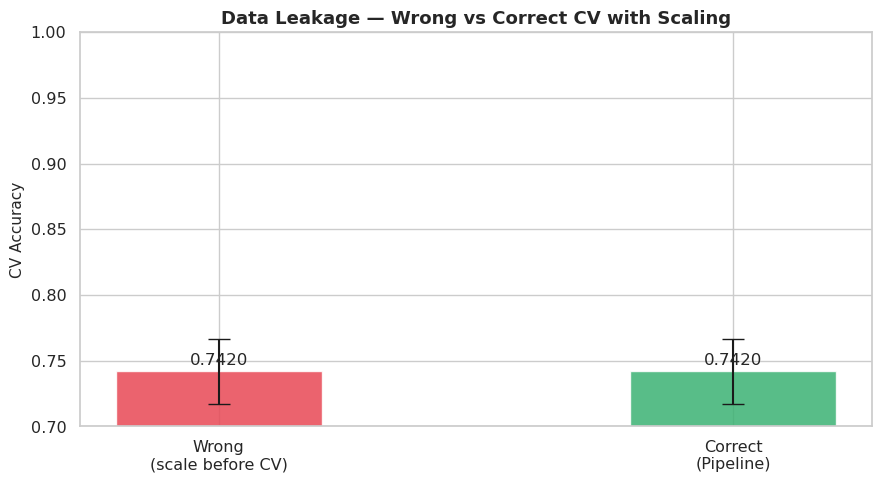

In [28]:
from sklearn.preprocessing import StandardScaler

# ── WRONG: scale before CV (data leakage!) ────────────────────────────────
X_scaled_wrong = StandardScaler().fit_transform(X_clf)  # sees ALL data!
model_wrong    = LogisticRegression(max_iter=1000, random_state=42)
scores_wrong   = cross_val_score(model_wrong, X_scaled_wrong, y_clf,
                                  cv=StratifiedKFold(5, shuffle=True, random_state=42),
                                  scoring='accuracy')

# ── CORRECT: scale inside pipeline (no leakage) ───────────────────────────
pipe_correct = Pipeline([
    ('sc',  StandardScaler()),   # fit only on train fold each time
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
scores_correct = cross_val_score(pipe_correct, X_clf, y_clf,
                                  cv=StratifiedKFold(5, shuffle=True, random_state=42),
                                  scoring='accuracy')

print('⚠️  WRONG (scaling before CV — data leakage):')
print(f'   Scores: {[round(s,4) for s in scores_wrong]}')
print(f'   Mean  : {scores_wrong.mean():.4f} ± {scores_wrong.std():.4f}')
print()
print('✅ CORRECT (scaling inside Pipeline — no leakage):')
print(f'   Scores: {[round(s,4) for s in scores_correct]}')
print(f'   Mean  : {scores_correct.mean():.4f} ± {scores_correct.std():.4f}')
print()
print('Note: On a clean synthetic dataset the difference may be minimal,')
print('but on real data with outliers or high variance, the gap can be significant.')

# Summary bar chart
fig, ax = plt.subplots(figsize=(9, 5))
methods = ['Wrong\n(scale before CV)', 'Correct\n(Pipeline)']
means   = [scores_wrong.mean(), scores_correct.mean()]
stds    = [scores_wrong.std(),  scores_correct.std()]
colors  = [COLORS['secondary'], COLORS['accent']]
bars    = ax.bar(methods, means, color=colors, alpha=0.85,
                  edgecolor='white', width=0.4, yerr=stds, capsize=8)
for bar, m in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, m+0.005,
            f'{m:.4f}', ha='center', fontsize=12)
ax.set_ylabel('CV Accuracy', fontsize=11)
ax.set_title('Data Leakage — Wrong vs Correct CV with Scaling',
             fontsize=13, fontweight='bold')
ax.set_ylim([0.7, 1.0])
plt.tight_layout(); plt.show()

---
## ✅ 12. Summary & Golden Rules

| CV Strategy | When to Use | sklearn Class |
|-------------|-------------|---------------|
| **KFold** | Regression, balanced classification | `KFold` |
| **StratifiedKFold** | Any classification (always safer) | `StratifiedKFold` |
| **LeaveOneOut** | Very small datasets (n < 50) | `LeaveOneOut` |
| **TimeSeriesSplit** | Time-ordered data | `TimeSeriesSplit` |
| **Nested CV** | Hyperparameter tuning + evaluation together | `GridSearchCV` inside `cross_val_score` |

### 🔑 Golden Rules

1. **Always use StratifiedKFold** for classification — preserves class ratios
2. **Always wrap preprocessing in a Pipeline** — prevents data leakage
3. **K=5 or K=10** is the standard choice for most datasets
4. **Use K=10 for small datasets** (< 500 samples), K=5 for large
5. **Use LOO only when n < 50** — computationally infeasible otherwise
6. **For time series, use TimeSeriesSplit** — never shuffle time-ordered data
7. **Use cross_validate for multiple metrics** — avoids redundant CV runs
8. **Use nested CV when reporting final performance after hyperparameter tuning**
9. **Report mean ± std** — a single number without std is incomplete
10. **Learning curves diagnose bias vs variance** — always plot before tuning

---

## 🔗 Next Steps

- ➡️ `05_Model_Evaluation/confusion_matrix.ipynb` — Precision, Recall, F1, AUC
- ➡️ `05_Model_Evaluation/bias_variance_tradeoff.md` — Understand what CV tells you
- ➡️ `07_Hyperparameter_Tuning/` — GridSearchCV, RandomizedSearchCV with CV
- ➡️ `08_Ensemble_Learning/` — Bagging/Boosting benefit from reliable CV estimates
